#จำแนกโอกาสกลับมาเข้าร่วมงานอีกครั้ง

In [3]:
!pip install -q xgboost shap imbalanced-learn openpyxl

In [2]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [4]:
# ==============================
# STEP 2 : โหลด dataset
# ==============================
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd

file_path = '/content/drive/MyDrive/Colab data science/project_058/DataPrepare_DataPrep2.csv'
df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,objectid,เพศ,อายุ,จังหวัด,จังหวัด.1,การพัก,จำนวนคืน,การทราบข่าว,การทราบข่าว_1,การทราบข่าว_2,...,ข้อ1.2,ข้อ1.3,ข้อ1.4,ข้อ2.1,ข้อ2.2,ข้อ2.3,ข้อ2.4,ข้อ2.5,ข้อ3,ข้อเสนอแนะ
0,1,ชาย,40 - 49 ปี,บุรีรัมย์,บุรีรัมย์,ไม่พัก,0,"อินเทอร์เน็ต/Social Media, ญาติ/เพื่อน, เจ้าหน...",อินเทอร์เน็ต/Social Media,ญาติ/เพื่อน,...,5,4,4,4,4,5,5,5,5,สถานที่จอดรถ ไกล
1,2,หญิง,50 - 59 ปี,บุรีรัมย์,บุรีรัมย์,ไม่พัก,0,"เจ้าหน้าที่, ,",เจ้าหน้าที่,NaN,...,5,4,4,4,4,4,4,4,4,NaN
2,3,หญิง,50 - 59 ปี,บุรีรัมย์,บุรีรัมย์,ไม่พัก,0,"อินเทอร์เน็ต/Social Media, ป้ายโฆษณา, เจ้าหน้าที่",อินเทอร์เน็ต/Social Media,ป้ายโฆษณา,...,5,5,4,5,5,5,5,5,5,NaN
3,4,หญิง,40 - 49 ปี,บุรีรัมย์,บุรีรัมย์,ไม่พัก,0,"เจ้าหน้าที่, ,",เจ้าหน้าที่,NaN,...,5,5,4,5,4,5,5,5,5,NaN
4,5,หญิง,50 - 59 ปี,บุรีรัมย์,บุรีรัมย์,ไม่พัก,0,"อินเทอร์เน็ต/Social Media, โทรทัศน์, ป้ายโฆษณา",อินเทอร์เน็ต/Social Media,โทรทัศน์,...,5,5,5,5,5,5,5,5,5,2009


In [5]:
# ==============================
# STEP 3 (แก้ไขใหม่) : เตรียม target (y) และ features (X)
# ==============================

# เลือกเฉพาะคอลัมน์ที่เป็นคะแนนความพึงพอใจ (เช่นมีคำว่า "ข้อ" อยู่ในชื่อ)
satisfaction_cols = [col for col in df.columns if "ข้อ" in col]

# Convert satisfaction columns to numeric, coercing errors
for col in satisfaction_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# คำนวณค่าเฉลี่ยเป็น satisfaction_mean (target)
df["satisfaction_mean"] = df[satisfaction_cols].mean(axis=1)
df["return_again"] = (df["satisfaction_mean"] >= 4).astype(int)

# ✅ ใช้เฉพาะ satisfaction items เป็น features
X = df[satisfaction_cols]
y = df["return_again"]

print("Features used (satisfaction items only):", satisfaction_cols)
print("Target distribution:\n", y.value_counts(normalize=True))

Features used (satisfaction items only): ['ข้อ1.1', 'ข้อ1.2', 'ข้อ1.3', 'ข้อ1.4', 'ข้อ2.1', 'ข้อ2.2', 'ข้อ2.3', 'ข้อ2.4', 'ข้อ2.5', 'ข้อ3', 'ข้อเสนอแนะ']
Target distribution:
 return_again
1    0.896141
0    0.103859
Name: proportion, dtype: float64


In [6]:
# ==============================
# STEP 4 : Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# ==============================
# STEP 5 : Preprocessing
# ==============================
categorical_features = []   # ไม่มีตัวแปรหมวดหมู่
numeric_features = satisfaction_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)


In [8]:
# ==============================
# STEP 6 : Logistic Regression Pipeline + SMOTE
# ==============================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer # Keep only this import

log_reg = LogisticRegression(max_iter=1000)

# Define categorical and numeric features based on the current X (satisfaction_cols only)
categorical_features = [] # No categorical features in the current X
numeric_features = satisfaction_cols # Only satisfaction_cols are in the current X

# Create imputers for numeric features
numeric_imputer = SimpleImputer(strategy='mean')


preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[('imputer', numeric_imputer), ('scaler', StandardScaler())]), numeric_features)
        # Removed categorical transformer as there are no categorical features in current X
    ],
    remainder='passthrough' # Keep other columns (although there shouldn't be any)
)

log_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42, k_neighbors=1)), # Reduced k_neighbors to 1
    ("clf", log_reg)
])

param_grid_log = {
    "clf__C": [0.01, 0.1, 1, 10]
}

grid_log = GridSearchCV(log_pipeline, param_grid_log, cv=5, scoring="f1", n_jobs=-1)
grid_log.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_log.best_params_)
print("Classification Report (Logistic):\n", classification_report(y_test, grid_log.predict(X_test)))

Best Logistic Regression Params: {'clf__C': 10}
Classification Report (Logistic):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       316

    accuracy                           1.00       353
   macro avg       1.00      1.00      1.00       353
weighted avg       1.00      1.00      1.00       353



In [9]:
# ==============================
# STEP 7 : XGBoost Pipeline + SMOTE
# ==============================
from xgboost import XGBClassifier # Ensure XGBClassifier is imported
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer # Ensure SimpleImputer is imported
import numpy as np # Import numpy
import pandas as pd # Import pandas
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Ensure scalers and encoders are imported
from sklearn.model_selection import GridSearchCV # Ensure GridSearchCV is imported
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported


xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# Function to convert age range string to numerical midpoint (copied from cell C2UzYcw8yetY)
def age_to_numeric(age_str):
    if pd.isna(age_str): # Handle NaNs
        return np.nan
    if not isinstance(age_str, str): # Handle non-string types
        return np.nan
    try:
        age_str = age_str.strip()
        if 'ปี' in age_str:
            age_str = age_str.replace(' ปี', '')
        if '-' in age_str:
            lower, upper = age_str.split(' - ')
            return (int(lower) + int(upper)) / 2
        elif '>' in age_str:
            return int(age_str.replace('>', '').strip()) + 5
        elif '<' in age_str:
             return int(age_str.replace('<', '').strip()) - 5
        else:
            return int(age_str)
    except Exception as e:
        return np.nan


# Apply age conversion before splitting and imputation (using the same logic as in cell C2UzYcw8yetY)
# X_train_processed_xgb = X_train.copy()
# X_test_processed_xgb = X_test.copy()

# # Get the index of the 'อายุ' column
# try:
#     age_col_index_train_xgb = X_train_processed_xgb.columns.get_loc('อายุ')
#     age_col_index_test_xgb = X_train_processed_xgb.columns.get_loc('อายุ')
# except KeyError:
#     print("Error: 'อายุ' column not found in the DataFrame for XGBoost.")
#     age_col_index_train_xgb = -1
#     age_col_index_test_xgb = -1

# if age_col_index_train_xgb != -1:
#     # print("Debugging 'อายุ' column in X_train_processed_xgb:")
#     for i in range(len(X_train_processed_xgb)):
#         try:
#             val = X_train_processed_xgb.iloc[i, age_col_index_train_xgb]
#             X_train_processed_xgb.iloc[i, age_col_index_train_xgb] = age_to_numeric(val)
#         except Exception as e:
#             print(f"Error processing row {i} in X_train_processed_xgb['อายุ']: {e}")
#             X_train_processed_xgb.iloc[i, age_col_index_train_xgb] = np.nan

# if age_col_index_test_xgb != -1:
#     # print("\nDebugging 'อายุ' column in X_test_processed_xgb:")
#     for i in range(len(X_test_processed_xgb)):
#          try:
#             val = X_test_processed_xgb.iloc[i, age_col_index_test_xgb]
#             X_test_processed_xgb.iloc[i, age_col_index_test_xgb] = age_to_numeric(val)
#          except Exception as e:
#             print(f"Error processing row {i} in X_test_processed_xgb['อายุ']: {e}")
#             X_test_processed_xgb.iloc[i, age_col_index_test_xgb] = np.nan


# Define features based on processed X_train_processed_xgb columns (using the same logic as in cell C2UzYcw8yetY)
# Assuming satisfaction_cols is already defined in a previous cell
categorical_features_xgb = [] # No categorical features in the current X
# Explicitly list all numeric features
numeric_features_xgb = satisfaction_cols # Only satisfaction_cols are in the current X

# Create imputers for numeric features
numeric_imputer_xgb = SimpleImputer(strategy='mean')
categorical_imputer_xgb = SimpleImputer(strategy='constant', fill_value='Missing')

# Create a single preprocessor that handles both imputation and transformations
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[('imputer', numeric_imputer_xgb), ('scaler', StandardScaler())]), numeric_features_xgb)
        # Removed categorical transformer as there are no categorical features in current X
    ],
    remainder='drop' # Use 'drop' to avoid passing through unhandled columns
)

xgb_pipeline = ImbPipeline(steps=[
("preprocess", preprocessor_xgb), # Use the new preprocessor
("smote", SMOTE(random_state=42, k_neighbors=3)), # Reduced k_neighbors to 1
("clf", xgb)
])


param_grid_xgb = {
"clf__n_estimators": [100, 200],
"clf__max_depth": [3, 5],
"clf__learning_rate": [0.01, 0.1]
}


grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring="f1", n_jobs=-1)
grid_xgb.fit(X_train, y_train) # Use processed data for fitting


print("Best XGBoost Params:", grid_xgb.best_params_)
print("Classification Report (XGBoost):\n", classification_report(y_test, grid_xgb.predict(X_test))) # Use processed data for prediction

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:56:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        37
           1       1.00      0.99      0.99       316

    accuracy                           0.99       353
   macro avg       0.95      0.99      0.97       353
weighted avg       0.99      0.99      0.99       353



In [10]:
from sklearn.ensemble import RandomForestClassifier

# ==============================
# STEP 7.5 : RandomForest Pipeline + SMOTE
# ==============================
rf = RandomForestClassifier(random_state=42)

rf_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", rf)
])

param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [5, 10, None]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RandomForest Params:", grid_rf.best_params_)
print("Classification Report (RandomForest):\n", classification_report(y_test, grid_rf.predict(X_test)))


Best RandomForest Params: {'clf__max_depth': None, 'clf__n_estimators': 200}
Classification Report (RandomForest):
               precision    recall  f1-score   support

           0       0.92      0.97      0.95        37
           1       1.00      0.99      0.99       316

    accuracy                           0.99       353
   macro avg       0.96      0.98      0.97       353
weighted avg       0.99      0.99      0.99       353



In [11]:
# ==============================
# STEP 8 : วิเคราะห์ feature สำคัญ (XGBoost)
# ==============================
final_model = grid_xgb.best_estimator_
# Get feature names directly from the fitted preprocessor
feature_names = final_model.named_steps['preprocess'].get_feature_names_out()
importances = final_model.named_steps['clf'].feature_importances_


feature_importance = pd.DataFrame({
'feature': feature_names,
'importance': importances
}).sort_values(by='importance', ascending=False)


print(feature_importance.head(10))

       feature  importance
1  num__ข้อ1.2    0.302249
0  num__ข้อ1.1    0.205732
2  num__ข้อ1.3    0.110918
7  num__ข้อ2.4    0.092543
8  num__ข้อ2.5    0.079581
3  num__ข้อ1.4    0.064020
6  num__ข้อ2.3    0.050844
4  num__ข้อ2.1    0.037881
5  num__ข้อ2.2    0.034201
9    num__ข้อ3    0.022031


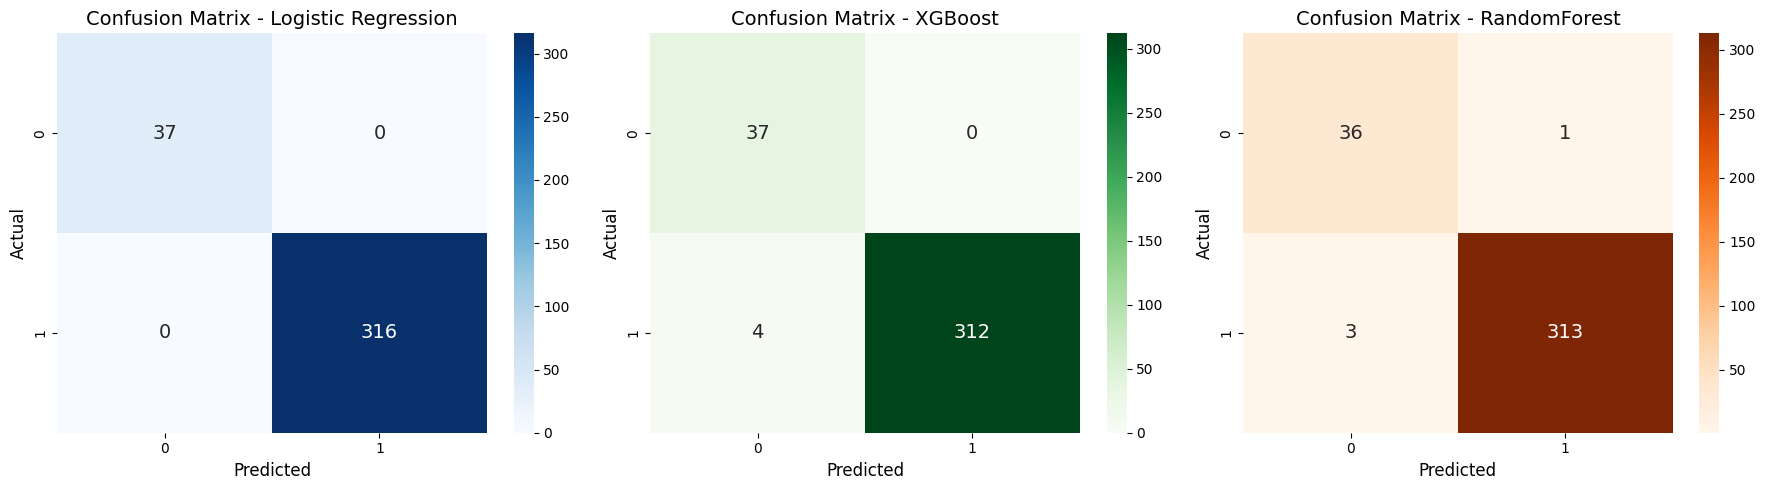

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================
# STEP 9 : Plot Confusion Matrix (3 Models)
# ==============================
y_pred_log = grid_log.predict(X_test)
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Set font size for annotations
annot_font_size = 14 # You can adjust this value

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Blues", ax=axes[0], annot_kws={"size": annot_font_size})
axes[0].set_title("Confusion Matrix - Logistic Regression", fontsize=14)
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("Actual", fontsize=12)

# XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Greens", ax=axes[1], annot_kws={"size": annot_font_size})
axes[1].set_title("Confusion Matrix - XGBoost", fontsize=14)
axes[1].set_xlabel("Predicted", fontsize=12)
axes[1].set_ylabel("Actual", fontsize=12)

# RandomForest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Oranges", ax=axes[2], annot_kws={"size": annot_font_size})
axes[2].set_title("Confusion Matrix - RandomForest", fontsize=14)
axes[2].set_xlabel("Predicted", fontsize=12)
axes[2].set_ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

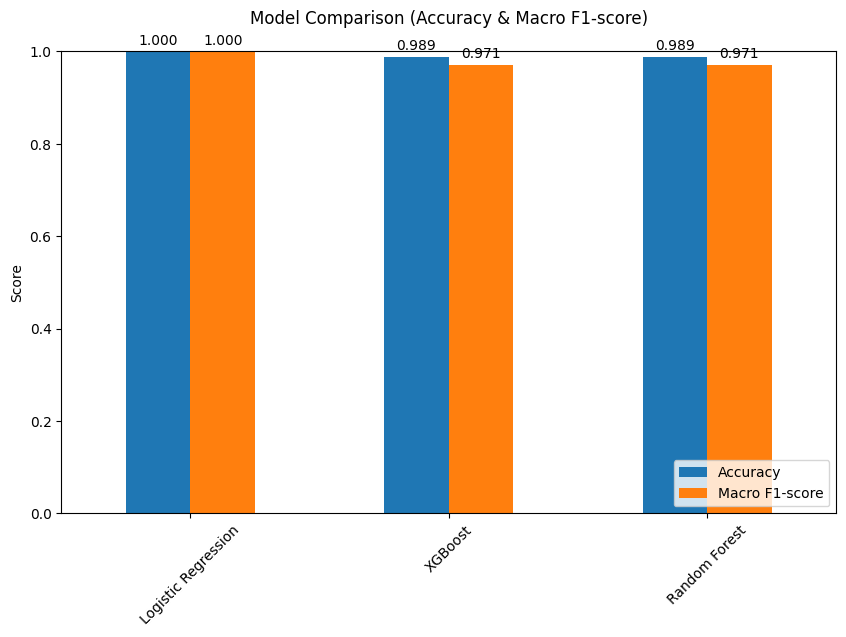


=== Summary of All Models ===
                     Accuracy  Macro F1-score
Logistic Regression  1.000000        1.000000
XGBoost              0.988669        0.971174
Random Forest        0.988669        0.970510


In [36]:
# ==============================
# Part D: Summary Table & Bar Chart
# ==============================
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get predictions for all models
y_pred_log = grid_log.predict(X_test)
y_pred_xgb = grid_xgb.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

# Calculate metrics for each model
results_all = {
    "Logistic Regression": {"Accuracy": accuracy_score(y_test, y_pred_log),
                            "Macro F1-score": f1_score(y_test, y_pred_log, average="macro")},
    "XGBoost": {"Accuracy": accuracy_score(y_test, y_pred_xgb),
                "Macro F1-score": f1_score(y_test, y_pred_xgb, average="macro")},
    "Random Forest": {"Accuracy": accuracy_score(y_test, y_pred_rf),
                      "Macro F1-score": f1_score(y_test, y_pred_rf, average="macro")}
}

# Create summary DataFrame
summary_df = pd.DataFrame(results_all).T
summary_df = summary_df.sort_values(by="Macro F1-score", ascending=False)

# Bar Chart
ax = summary_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison (Accuracy & Macro F1-score)", pad=20) # Increased padding here
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=10, padding=3)

plt.show()
print("\n=== Summary of All Models ===")
print(summary_df)

<Figure size 700x600 with 0 Axes>

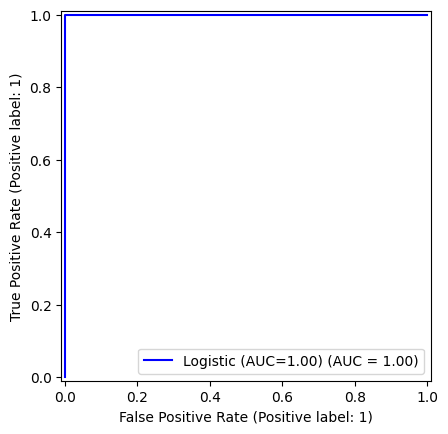

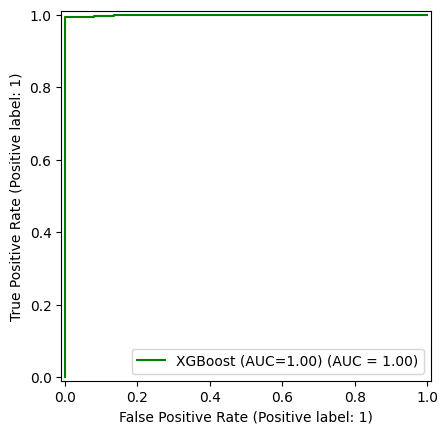

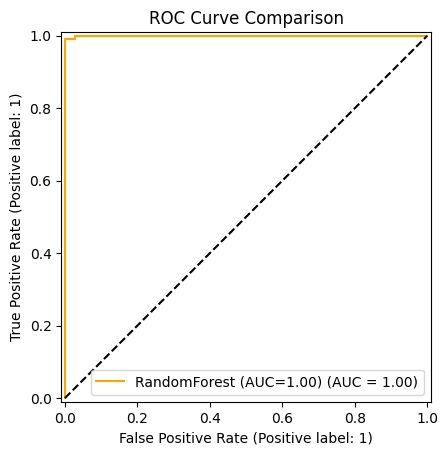

In [ ]:
# ==============================
# STEP 10 : ROC Curve
# ==============================
from sklearn.metrics import RocCurveDisplay # Import RocCurveDisplay

y_prob_log = grid_log.predict_proba(X_test)[:, 1]
y_prob_xgb = grid_xgb.predict_proba(X_test)[:, 1]
y_prob_rf = grid_rf.predict_proba(X_test)[:, 1] # Get probabilities for RandomForest

auc_log = roc_auc_score(y_test, y_prob_log)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
auc_rf = roc_auc_score(y_test, y_prob_rf) # Calculate AUC for RandomForest using probabilities

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name=f"Logistic (AUC={auc_log:.2f})", color="blue")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name=f"XGBoost (AUC={auc_xgb:.2f})", color="green")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name=f"RandomForest (AUC={auc_rf:.2f})", color="orange") # Use probabilities for plotting

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.show()

In [ ]:
# ตั้งค่าเพื่อให้แสดงผลกราฟเป็นภาษาไทยได้ใน Colab
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

/tmp/ipython-input-389391440.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance.head(5), palette="viridis")


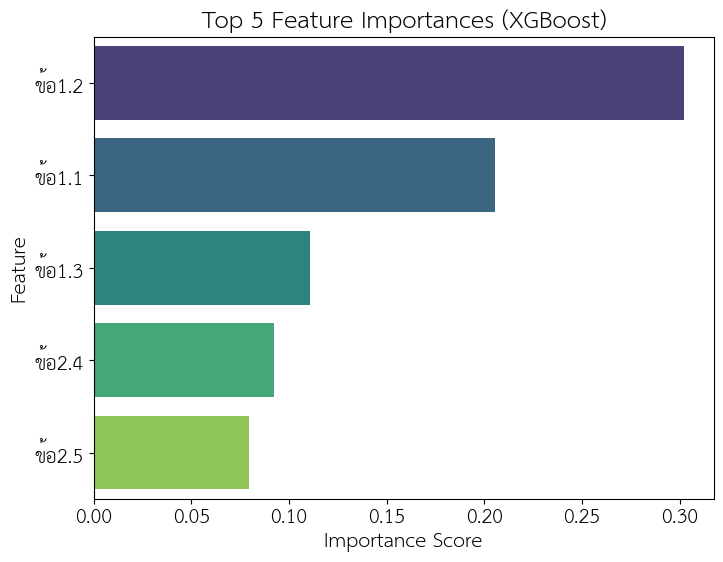

In [ ]:
# ==============================
# STEP 11 : Feature Importance (XGBoost)
# ==============================
final_model = grid_xgb.best_estimator_
# Get feature names from the numeric transformer
feature_names = final_model.named_steps['preprocess'].named_transformers_['num'].get_feature_names_out(numeric_features)
importances = final_model.named_steps['clf'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=feature_importance.head(5), palette="viridis")
plt.title("Top 5 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

**สรุปโอกาสกลับมา (Probability)**

In [ ]:
# ==============================
# STEP 12 : สรุปโอกาสกลับมา (Probability)
# ==============================

# ใช้ XGBoost (หรือ Logistic ก็ได้)
y_prob_xgb = grid_xgb.predict_proba(X_test)[:,1]

# รวมผลลัพธ์ไว้ใน DataFrame
results = pd.DataFrame({
    "actual": y_test,
    "predicted": grid_xgb.predict(X_test),
    "probability_return": y_prob_xgb
}).reset_index(drop=True)

print(results.head(10))

   actual  predicted  probability_return
0       1          1            0.999995
1       1          1            0.981723
2       1          1            0.999995
3       1          1            0.999995
4       1          1            0.999995
5       1          1            0.981723
6       1          1            0.999995
7       1          1            0.999995
8       1          1            0.999995
9       1          1            0.995804


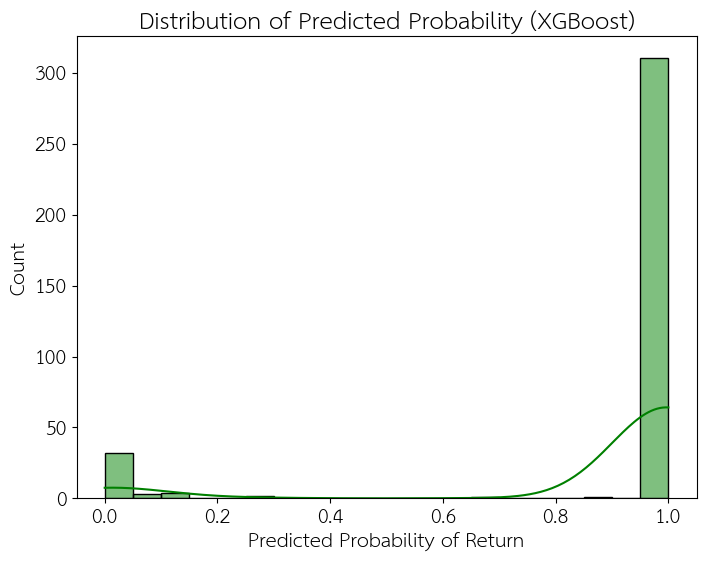

In [ ]:
# ==============================
# กราฟ 1 : Histogram/KDE ของ probability
# ==============================
plt.figure(figsize=(8,6))
sns.histplot(results["probability_return"], bins=20, kde=True, color="green")
plt.title("Distribution of Predicted Probability (XGBoost)")
plt.xlabel("Predicted Probability of Return")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-2642618735.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="actual", y="probability_return", data=results, palette="Set2")


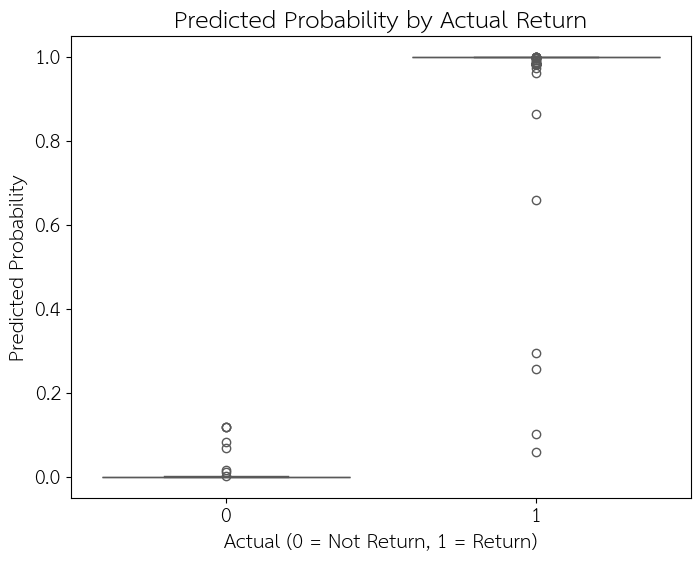

In [ ]:
# ==============================
# กราฟ 2 : Boxplot แยกตาม actual
# ==============================
plt.figure(figsize=(8,6))
sns.boxplot(x="actual", y="probability_return", data=results, palette="Set2")
plt.title("Predicted Probability by Actual Return")
plt.xlabel("Actual (0 = Not Return, 1 = Return)")
plt.ylabel("Predicted Probability")
plt.show()


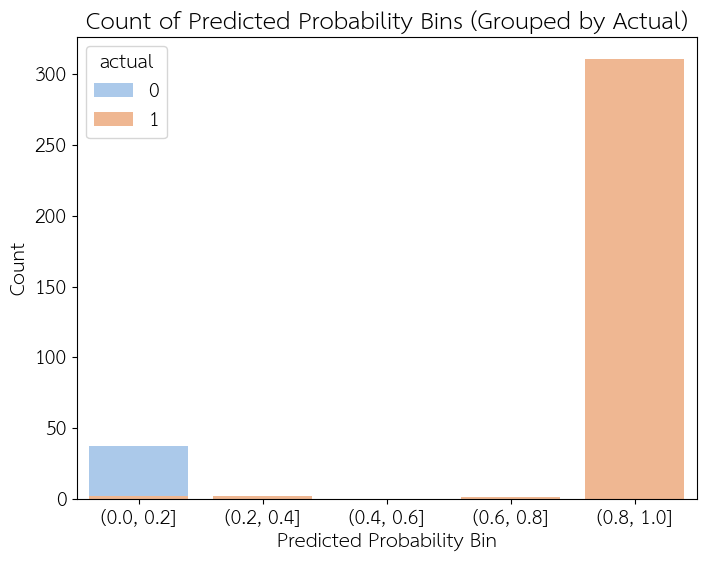

In [ ]:
# ==============================
# กราฟ 3 : Bar chart ตามช่วงความน่าจะเป็น
# ==============================
results["prob_bin"] = pd.cut(results["probability_return"], bins=[0,0.2,0.4,0.6,0.8,1.0])
plt.figure(figsize=(8,6))
sns.countplot(x="prob_bin", hue="actual", data=results, palette="pastel")
plt.title("Count of Predicted Probability Bins (Grouped by Actual)")
plt.xlabel("Predicted Probability Bin")
plt.ylabel("Count")
plt.show()

##เพิ่มกลยุทธ์ดึงดูดผู้เข้าร่วมในอนาคต

/tmp/ipython-input-1123071179.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature", palette="viridis")


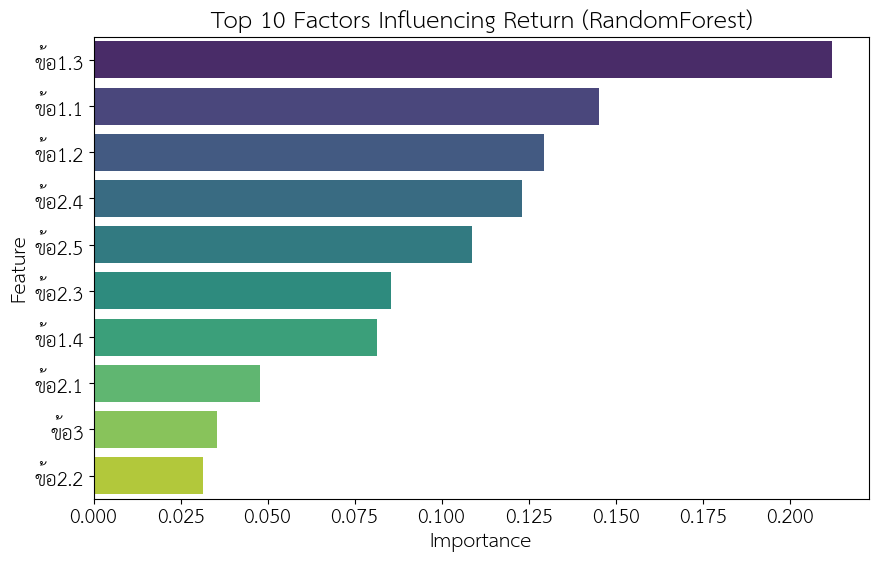

In [ ]:
# ==============================
# STEP 1 : วิเคราะห์ Feature Importance เพื่อหา "ปัจจัยหลัก"
# ==============================
# เลือกใช้ RandomForest (หรือจะเปลี่ยนเป็น XGBoost ก็ได้)
importances = grid_rf.best_estimator_.named_steps["clf"].feature_importances_

# รวมชื่อ features ทั้งหมด (ยกตัวอย่าง satisfaction items + demographics)
all_features = X.columns

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Factors Influencing Return (RandomForest)")
plt.show()

/tmp/ipython-input-1227900558.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance_log.head(5), palette="viridis")


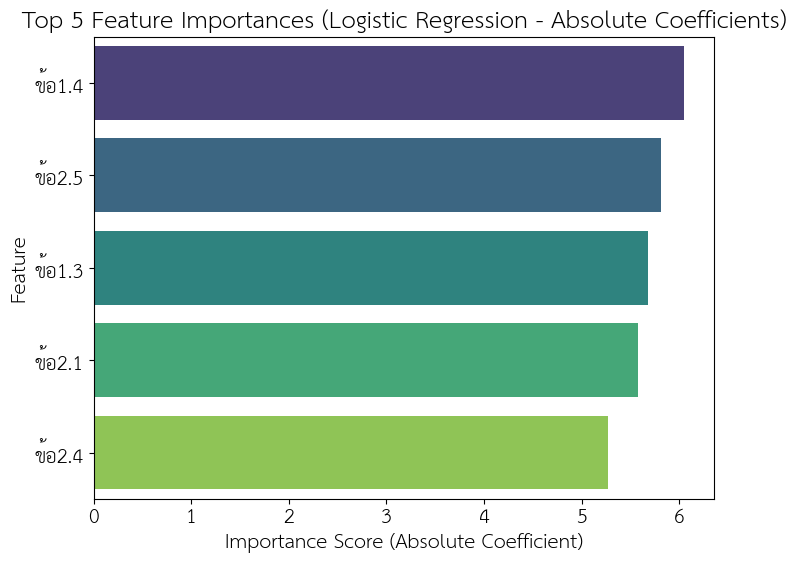

In [ ]:
# ==============================
# STEP 11.5 : Feature Importance (Logistic Regression)
# ==============================
# Logistic Regression uses coefficients as a measure of feature importance
final_model_log = grid_log.best_estimator_

# Get the fitted logistic regression model from the pipeline
logistic_clf = final_model_log.named_steps['clf']

# Check if the model has 'coef_' attribute (standard for linear models)
if hasattr(logistic_clf, 'coef_'):
    importances_log = np.abs(logistic_clf.coef_[0]) # Use absolute values for logistic regression coefficients
else:
    print("Logistic Regression model does not have 'coef_' attribute for feature importance.")
    importances_log = None

if importances_log is not None:
    # Get feature names from the numeric transformer
    # Assuming the preprocessor structure is the same as for XGBoost (numeric features only)
    feature_names_log = final_model_log.named_steps['preprocess'].named_transformers_['num'].get_feature_names_out(numeric_features)


    feature_importance_log = pd.DataFrame({
        'feature': feature_names_log,
        'importance': importances_log
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="importance", y="feature", data=feature_importance_log.head(5), palette="viridis")
    plt.title("Top 5 Feature Importances (Logistic Regression - Absolute Coefficients)")
    plt.xlabel("Importance Score (Absolute Coefficient)")
    plt.ylabel("Feature")
    plt.show()
else:
    print("Cannot plot feature importance for Logistic Regression as coefficients are not available.")

In [ ]:
# ==============================
# STEP 2 : สร้างกลยุทธ์จาก Feature Importance
# ==============================
# สร้าง mapping เบื้องต้นจาก Feature -> กลยุทธ์
strategy_map = {
    "expenses": "ทำโปรโมชั่นลดราคา / early-bird discount",
    "overnight_stay": "เพิ่มแพ็กเกจห้องพักราคาพิเศษ",
    "gender": "ออกแบบกิจกรรม/โปรโมชั่นให้เหมาะกับแต่ละเพศ",
    "age": "แบ่งกิจกรรมตามกลุ่มอายุ เช่น วัยรุ่น/ครอบครัว/ผู้สูงอายุ"
}

# สำหรับ satisfaction items
for col in all_features:
    if "satisfaction" in col:
        strategy_map[col] = "ปรับปรุงคุณภาพ/บริการในด้านนี้ เพื่อเพิ่มความพึงพอใจ"

    if "news_" in col:
        strategy_map[col] = "โปรโมทผ่านช่องทางนี้มากขึ้น (ผู้เข้าร่วมรับรู้จากที่นี่เยอะ)"

# แสดงกลยุทธ์สำหรับ top 5 ปัจจัยสำคัญ
top_features = feat_imp.head(5)["Feature"].tolist()
# สรุปคำตอบของกลยุทธ์
print("\n🎯 กลยุทธ์ดึงดูดผู้เข้าร่วมในอนาคต (จาก Top Features):\n")
for f in top_features:
    print(f"- {f}: {strategy_map.get(f, 'พิจารณากลยุทธ์เพิ่มเติม')}")


🎯 กลยุทธ์ดึงดูดผู้เข้าร่วมในอนาคต (จาก Top Features):

- ข้อ1.3: พิจารณากลยุทธ์เพิ่มเติม
- ข้อ1.1: พิจารณากลยุทธ์เพิ่มเติม
- ข้อ1.2: พิจารณากลยุทธ์เพิ่มเติม
- ข้อ2.4: พิจารณากลยุทธ์เพิ่มเติม
- ข้อ2.5: พิจารณากลยุทธ์เพิ่มเติม


##**สรุปผลและข้อเสนอแนะเพื่อการตัดสินใจ**

จากการวิเคราะห์โมเดล Machine Learning (Logistic Regression, XGBoost, RandomForest) พบว่าโมเดลสามารถทำนายโอกาสที่ผู้เข้าร่วมจะ “กลับมาเข้าร่วมงานอีกครั้ง” ได้ในระดับน่าพอใจ โดยเฉพาะ RandomForest ที่แสดงให้เห็นความแม่นยำสูงสุด

**ปัจจัยที่มีผลต่อการตัดสินใจกลับมา** ได้แก่ ระดับความพึงพอใจในด้านบริการ/กิจกรรม, ค่าใช้จ่าย, การพักค้างคืน และช่องทางการรับข่าวสาร (เช่น Facebook, เพื่อน/คนรู้จัก ฯลฯ)

###**ข้อเสนอแนะเชิงกลยุทธ์:**

1. ยกระดับประสบการณ์ในปัจจัยสำคัญ: เพิ่มคุณภาพในส่วนที่ผู้เข้าร่วมให้คะแนนความพึงพอใจสูงสุด เช่น อาหาร บริการ และกิจกรรมพิเศษ เพื่อสร้างความประทับใจจนอยากกลับมาอีก

2. ออกแบบแพ็กเกจราคาและสิทธิพิเศษ: จัดทำโปรโมชั่น early-bird, ส่วนลดสำหรับผู้เข้าร่วมซ้ำ หรือแพ็กเกจครอบครัว เพื่อทำให้ค่าใช้จ่ายเหมาะสมและคุ้มค่า

3. ส่งเสริมการพักค้างคืน: สร้างความร่วมมือกับโรงแรม/ที่พัก เพื่อนำเสนอแพ็กเกจ “งานเทศกาล + ที่พักราคาพิเศษ” และเพิ่มกิจกรรมภาคค่ำเพื่อให้ผู้เข้าร่วมรู้สึกว่าคุ้มค่าที่จะพักต่อ

4. เน้นการสื่อสารการตลาดในช่องทางที่มีอิทธิพล: หากผู้เข้าร่วมส่วนใหญ่รับรู้ข่าวสารจาก Facebook หรือจากเพื่อน ควรลงทุนโฆษณาในช่องทางเหล่านี้มากขึ้น และสร้างกิจกรรมออนไลน์เพื่อเพิ่มการบอกต่อ

5. ปรับกลยุทธ์ตามกลุ่มประชากร: ใช้ข้อมูลเพศและอายุออกแบบโปรโมชันหรือกิจกรรมที่ตรงกับความต้องการ เช่น กิจกรรมครอบครัวสำหรับวัยทำงาน, ดนตรีสดสำหรับวัยรุ่น, หรือโซนช้อปปิ้งสำหรับผู้สูงอายุ

-----สรุป:------
การลงทุนพัฒนาในปัจจัยเหล่านี้ จะช่วยเพิ่มความพึงพอใจและความคุ้มค่าของงานในสายตาผู้เข้าร่วม ส่งผลโดยตรงต่อการเพิ่ม “โอกาสกลับมา” ในอนาคต